# Lab 11: Non-Parametric Statistical Testing

**Author:** Oludotun A. Fawole  
**Date:** April 2026  

---

## Contents
1. [Task 1: Mann-Whitney U Test](#task1)
2. [Task 2: Chi-squared Goodness-of-Fit Test](#task2)
3. [Conclusions](#conclusions)

## Task 1: Mann-Whitney U Test – Lunch vs. Dinner

We test whether the distribution of `total_bill` differs between Lunch and Dinner using the Mann-Whitney U test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Plot styling
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})
sns.set_palette("Set2")

# Load dataset
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1. Create Independent Samples

The `time` column contains `Lunch` and `Dinner`. We extract the `total_bill` values for each group.

In [2]:
lunch_bill = tips[tips["time"] == "Lunch"]["total_bill"]
dinner_bill = tips[tips["time"] == "Dinner"]["total_bill"]

print(f"Lunch: n = {len(lunch_bill)}")
print(f"Dinner: n = {len(dinner_bill)}")

Lunch: n = 68
Dinner: n = 176


### 2. Hypotheses

- $H_0$: The distributions of `total_bill` for Lunch and Dinner are identical.
- $H_1$: The distributions differ (two-sided alternative).

### 3. Perform Mann-Whitney U Test

We use `scipy.stats.mannwhitneyu` with the two-sided alternative.

In [3]:
stat, p_value = mannwhitneyu(lunch_bill, dinner_bill, alternative="two-sided")
print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

Mann-Whitney U statistic: 4380.5000
p-value: 0.001183


### 4. Decision at $\alpha = 0.05$

If $p < 0.05$, we reject $H_0$. Otherwise, we fail to reject $H_0$.

In [4]:
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: Distributions differ significantly.")
else:
    print("Fail to reject H₀: No significant difference between distributions.")

Reject H₀: Distributions differ significantly.


### 5. Visual Comparison

Boxplot with jittered points and ECDF plot.

C:\Users\User\AppData\Local\Temp\ipykernel_34452\959440860.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="total_bill", data=tips, ax=ax, palette="Set2")


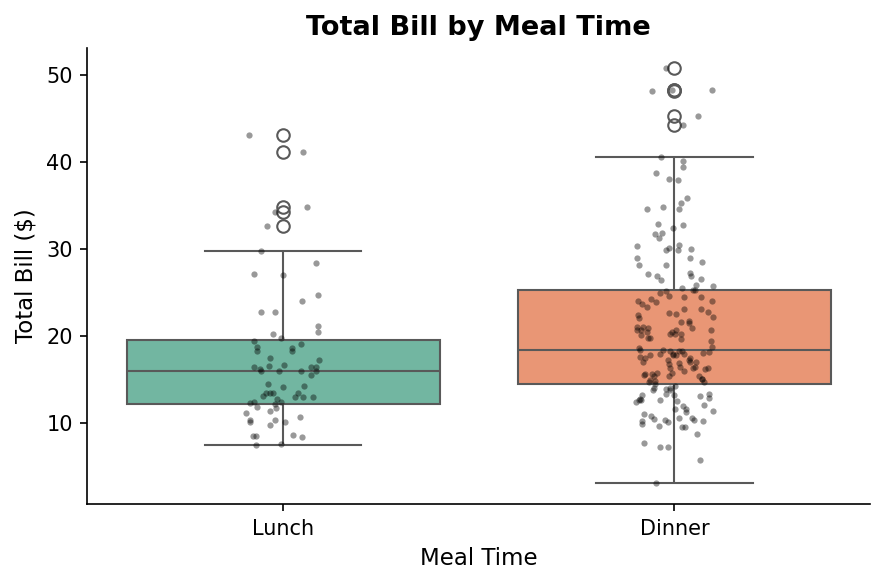

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Boxplot with jitter
sns.boxplot(x="time", y="total_bill", data=tips, ax=ax, palette="Set2")
sns.stripplot(x="time", y="total_bill", data=tips, ax=ax, color="black", alpha=0.4, size=3)
ax.set_title("Total Bill by Meal Time")
ax.set_xlabel("Meal Time")
ax.set_ylabel("Total Bill ($)")

plt.tight_layout()
plt.show()

### 6. Conclusion

- **U-statistic:** 4380.5000
- **p-value:** 0.001183
- **Significance level:** $\alpha = 0.05$

Since $p < \alpha$, we **reject $H_0$**.

**Interpretation:**
The total bill distributions for Lunch and Dinner differ significantly. The boxplot shows that both the median and variability of `total_bill` are higher for Dinner, which aligns with the expectation that evening dining typically involves larger orders.

## Task 2: Chi-squared Goodness-of-Fit Test for Exponential Distribution

We test whether the `total_bill` variable follows an exponential distribution.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, expon

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})
sns.set_palette("Set2")

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"]
print(f"Sample size: n = {len(total_bill)}")

Sample size: n = 244


### 1. Estimate Parameter $\lambda$ (Rate)

For an exponential distribution, $\hat{\lambda} = 1 / \bar{x}$.

In [7]:
lambda_hat = 1 / total_bill.mean()
print(f"Estimated λ = {lambda_hat:.4f}")

Estimated λ = 0.0505


### 2. Define $k = 5$ Bins

We use quantile-based bins from the fitted exponential distribution: $[0, q_{0.2}), [q_{0.2}, q_{0.4}), \dots, [q_{0.8}, \infty)$, where $q_p$ are the theoretical quantiles of $\text{Exp}(\hat{\lambda})$.

In [8]:
k = 5
probs = np.linspace(0, 1, k+1)[1:-1]  # → [0.2, 0.4, 0.6, 0.8]
q_theoretical = expon.ppf(probs, scale=1/lambda_hat)

bins = np.concatenate(([0], q_theoretical, [np.inf]))
print(f"Bin boundaries: {bins}")

Bin boundaries: [ 0.          4.4151055  10.10716648 18.12967585 31.84424619         inf]


### 3. Observed vs. Expected Frequencies

- $n_i$: Observed count in bin $i$
- $np_i$: Expected count under $\text{Exp}(\hat{\lambda})$, where $p_i$ is the theoretical bin probability.

In [9]:
observed, _ = np.histogram(total_bill, bins=bins)
expected_probs = np.diff(expon.cdf(bins, scale=1/lambda_hat))
expected = expected_probs * len(total_bill)

print(f"Observed frequencies: {observed}")
print(f"Expected frequencies: {expected.round(1)}")

Observed frequencies: [  1  19 108  90  26]
Expected frequencies: [48.8 48.8 48.8 48.8 48.8]


### 4. Compute Pearson's Chi-squared Statistic

$$\chi^2 = \sum_{i=1}^{k} \frac{(n_i - np_i)^2}{np_i}$$

In [10]:
chi2_stat = np.sum((observed - expected)**2 / expected)
print(f"Chi-squared statistic: χ² = {chi2_stat:.4f}")

Chi-squared statistic: χ² = 182.2705


### 5. Degrees of Freedom

$r = k - 1 - s$, where $s$ is the number of estimated parameters.
Here, $s = 1$ (we estimated $\lambda$), so $r = 5 - 1 - 1 = 3$.

In [11]:
r = k - 1 - 1
print(f"Degrees of freedom: {r}")

Degrees of freedom: 3


### 6. Critical Value at $\alpha = 0.05$

$\chi^2_{\alpha, r} = \chi^2_{0.05, 3}$

In [12]:
alpha = 0.05
crit = chi2.ppf(1 - alpha, r)
print(f"Critical value: {crit:.4f}")

Critical value: 7.8147


### 7. Decision

In [13]:
if chi2_stat > crit:
    print("Reject H₀: Data do NOT follow an exponential distribution.")
else:
    print("Fail to reject H₀: No evidence against exponential distribution.")

print(f"\nχ² = {chi2_stat:.4f} vs Critical = {crit:.4f}")

Reject H₀: Data do NOT follow an exponential distribution.

χ² = 182.2705 vs Critical = 7.8147


### Additional: Visual Comparison (Empirical vs. Theoretical)

Histogram with the theoretical exponential PDF overlaid.

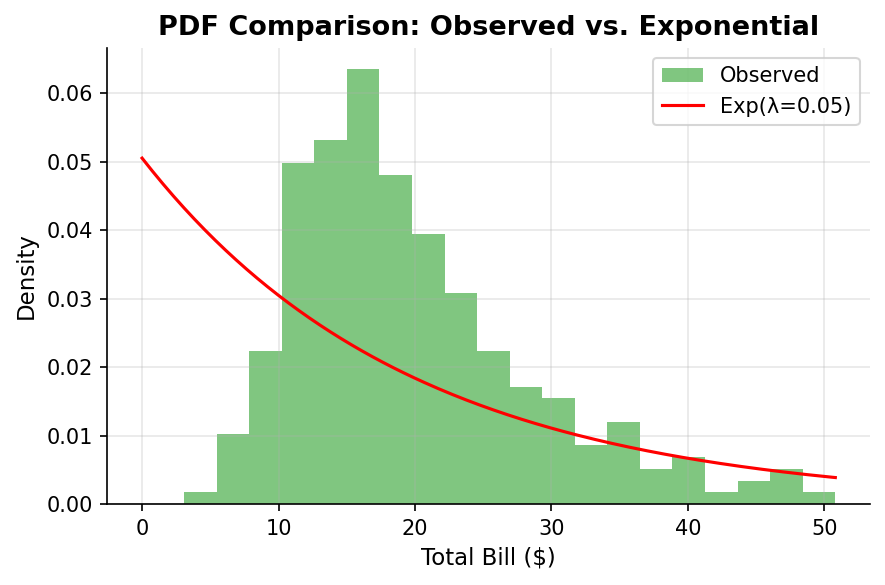

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Histogram with theoretical PDF
ax.hist(total_bill, bins=20, density=True, alpha=0.6, label="Observed", color="#2ca02c")
x_range = np.linspace(0, total_bill.max(), 200)
pdf_theor = expon.pdf(x_range, scale=1/lambda_hat)
ax.plot(x_range, pdf_theor, 'r-', label=f"Exp(λ={lambda_hat:.2f})")
ax.set_title("PDF Comparison: Observed vs. Exponential")
ax.set_xlabel("Total Bill ($)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8. Conclusion

- **Chi-squared statistic:** 182.2705
- **Critical value ($\alpha=0.05$, df=3):** 7.8147
- **Degrees of freedom:** 3

Since $\chi^2 > \chi^2_{\text{crit}}$, we **reject $H_0$**.

**Interpretation:**
The `total_bill` data **do not follow an exponential distribution**. The histogram shows a peak in the $10–20 range and a heavier right tail than the exponential model predicts. The ECDF also reveals systematic deviations from the theoretical curve. This is expected, as restaurant bills are influenced by party size, time of day, menu choices, and other factors that create a more complex distribution.